# Geo Experiment — Split Design Notebook

This notebook walks through how we divided US markets into **Treatment** and **Control** groups for a geo-based randomised experiment.

**What we're doing, in plain English:**
1. Load our transaction data from Braintree
2. Group US transactions by geographic market (called a DMA)
3. Check which markets have reliable data
4. Split markets into two balanced groups — Treatment (gets the campaign) and Control (doesn't)
5. Verify the split is fair before we run anything

---
> **DMA** = Designated Market Area. Think of it as a TV broadcast region — e.g. "New York", "Los Angeles", "Chicago". There are ~200 DMAs across the US.

## Step 0 — Setup
Load the libraries we need. Run this cell first every time you open the notebook.

In [2]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

BASE_DIR = os.getcwd()   # folder where this notebook lives
print('Ready.')

Ready.


---
## Step 1 — Load the raw Braintree data

We read every transaction exported from Braintree. At this stage we just want to see what's in the file — no changes yet.

In [3]:
BRAINTREE_CSV = os.path.join(BASE_DIR, 'Braintree data - March 2026 - Sheet1.csv')

raw = pd.read_csv(BRAINTREE_CSV, dtype=str)
raw.columns = raw.columns.str.strip()

print(f'Total rows loaded : {len(raw):,}')
raw.head(5)

Total rows loaded : 40,831


,Transaction ID,Transaction Type,Transaction Status,Created Datetime,Created Timezone,Settlement Date,Merchant Account,Currency ISO Code,Amount Authorized,Amount Submitted For Settlement,...,Billing Company,Billing Street Address,Billing Extended Address,Billing City (Locality),Billing State/Province (Region),Billing Postal Code,Billing Country,IP Address,Creating Using Token,Transaction Source
0,00001rxw,sale,voided,04/07/2025 9:44:41,BST,NaN,plumEUR,EUR,829.88,829.88,...,NaN,14 Allee du golf,NaN,Mallemort,NaN,13470,France,137.135.180.22,Yes,API
1,00rdgja1,sale,settled,02/21/2025 0:54:29,GMT,02/21/2025,theplumguide_instant,USD,1578.13,1578.13,...,NaN,960 E Green Street,Suite 202,Pasadena,CA,91106,United States of America,137.135.180.18,No,API
2,01qgt9fq,sale,settled,03/27/2025 5:23:05,GMT,04/01/2025,theplumguide_instant,USD,864.47,864.47,...,NaN,2582 Lake View Avenue,Los Angeles,Los Angeles,CA,90039,United States of America,137.135.180.17,No,API
3,03ay064x,sale,processor_declined,04/02/2025 16:01:40,BST,NaN,theplumguide_instant,USD,2513,NaN,...,NaN,640 N Wells St,Apt 1210,Chicago,IL,60654,United States of America,137.135.180.27,No,API
4,05ce7157,sale,processor_declined,04/04/2025 23:01:09,BST,NaN,theplumguide_instant,USD,1378.76,NaN,...,NaN,P O Box 65,NaN,Florence,CO,81226,United States of America,137.135.180.21,No,API


---
## Step 2 — Filter and clean

We only keep transactions that are:
- **In the United States** — experiment is US-only
- **Not credits / refunds** — credits would reduce our booking count incorrectly

We also parse the date and extract the week start (Monday) for each transaction.

In [14]:
# Keep US only
us = raw[raw['Billing Country'].str.strip() == 'United States of America'].copy()

# Remove refunds / credits
us = us[us['Transaction Type'].str.strip().str.lower() != 'credit'].copy()

# Parse the transaction date, then find the Monday of that week
us['date'] = pd.to_datetime(us['Created Datetime'], format='%m/%d/%Y %H:%M:%S', errors='coerce')
us['week'] = (us['date'] - pd.to_timedelta(us['date'].dt.dayofweek, unit='d')).dt.normalize()

# Parse dollar amount
us['Amount Authorized'] = pd.to_numeric(us['Amount Authorized'], errors='coerce')

# Clean ZIP code: keep first 5 digits, zero-pad short ones
us['postal_code'] = (
    us['Billing Postal Code'].str.strip()
    .str.split('-').str[0]
    .str.zfill(5)
)

print(f'US transactions kept : {len(us):,}')
print(f'Date range           : {us["date"].min().date()}  to  {us["date"].max().date()}')
print(f'Unique ZIP codes     : {us["postal_code"].nunique():,}')

US transactions kept : 17,589
Date range           : 2025-01-02  to  2026-03-03
Unique ZIP codes     : 3,885


/var/folders/rx/wb565c7s59z564wmtx5yf5rc0000gn/T/ipykernel_46997/2353544604.py:9: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  us['week'] = (us['date'] - pd.to_timedelta(us['date'].dt.dayofweek, unit='d')).dt.normalize()


---
## Step 3 — Roll up to weekly bookings per ZIP code

Instead of one row per transaction, we want one row per **week + ZIP code** showing how many bookings happened that week.

In [24]:
weekly_zip = (
    us.groupby(['week', 'postal_code'])
    .agg(
        bookings = ('Transaction ID', 'nunique'),
        sales    = ('Amount Authorized', 'sum'),
    )
    .reset_index()
)

print(f'Weeks in data    : {weekly_zip["week"].nunique()}')
print(f'Unique ZIP codes : {weekly_zip["postal_code"].nunique():,}')
weekly_zip.head(6)

Weeks in data    : 62
Unique ZIP codes : 3,885


,week,postal_code,bookings,sales
0,2024-12-30,01002,2,1969.59
1,2024-12-30,01120,1,1161.20
2,2024-12-30,01741,1,1210.86
3,2024-12-30,02108,1,3819.60
4,2024-12-30,02360,1,1038.67
5,2024-12-30,04110,2,978.00


---
## Step 4 — Map ZIP codes to DMAs

Each ZIP code belongs to a DMA (media market). We load a reference table that maps ZIP to DMA, then attach it to our data.

After this step, instead of ~30,000 ZIP codes we'll work with ~160 DMAs — much easier to analyse.

In [33]:
ZIP_PATH  = os.path.join(BASE_DIR, '023882f8d77741f4d5347f80d95bc259-f9f3424dbe4fb58b3dac65dced4c1c3a0f0db27a.zip')
ZIP_ENTRY = '023882f8d77741f4d5347f80d95bc259-f9f3424dbe4fb58b3dac65dced4c1c3a0f0db27a/Zip Codes to DMAs'

with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open(ZIP_ENTRY) as f:
        dma_map = pd.read_csv(f, sep='\t', dtype=str)

dma_map.columns = dma_map.columns.str.strip()
dma_map['zip_code'] = dma_map['zip_code'].str.strip().str.zfill(5)
dma_map = dma_map.rename(columns={'zip_code': 'postal_code'})

# Attach DMA to each ZIP row
weekly = weekly_zip.merge(dma_map, on='postal_code', how='left')
weekly['dma_mapped'] = weekly['dma_code'].notna()

print(f'ZIPs successfully mapped to a DMA : {weekly["dma_mapped"].mean():.1%}')

# Drop rows with no DMA match
weekly = weekly[weekly['dma_mapped']].copy()
print(f'Rows kept after mapping           : {len(weekly):,}')

ZIPs successfully mapped to a DMA : 98.9%
Rows kept after mapping           : 12,130


---
## Step 5 — Roll up to weekly bookings per DMA

Sum all ZIP codes within a DMA to get one number per market per week.

Unique DMAs  : 187
Unique weeks : 62


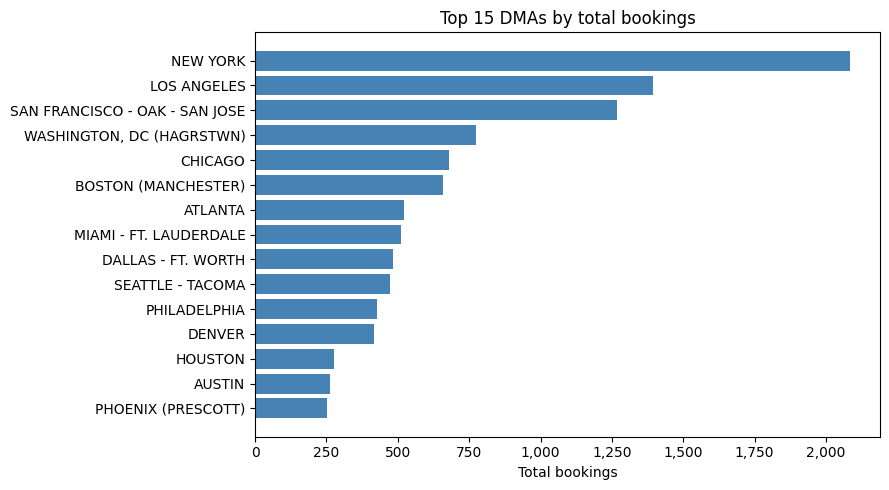

In [41]:
dma_weekly = (
    weekly.groupby(['week', 'dma_description'])
    .agg(bookings=('bookings', 'sum'), sales=('sales', 'sum'))
    .reset_index()
    .rename(columns={'dma_description': 'dma'})
)

print(f'Unique DMAs  : {dma_weekly["dma"].nunique()}')
print(f'Unique weeks : {dma_weekly["week"].nunique()}')

# Chart: top 15 DMAs by total bookings
top_dmas = (
    dma_weekly.groupby('dma')['bookings'].sum()
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_dmas.index, top_dmas.values, color='steelblue')
ax.set_xlabel('Total bookings')
ax.set_title('Top 15 DMAs by total bookings')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## Step 6 — Keep only DMAs with consistent data

Some DMAs only appear in a few weeks. If we include them, they'll drop in and out of our experiment windows and produce unreliable results.

**Rule:** Keep only DMAs present in at least X% of all weeks (starting from 100%, relaxing until we drop no more than 20% of DMAs).

Threshold : 9% of 62 weeks
Kept      : 131 DMAs
Dropped   : 30 DMAs

Dropped DMAs (incomplete data):
                             dma  weeks_present      pct
            ABILENE - SWEETWATER              3 0.048387
                     BAKERSFIELD              5 0.080645
                          BANGOR              5 0.080645
          BEAUMONT - PORT ARTHUR              4 0.064516
                        BILLINGS              4 0.064516
               BILOXI - GULFPORT              3 0.048387
                      BINGHAMTON              4 0.064516
         CHARLESTON - HUNTINGTON              3 0.048387
           CHEYENNE - SCOTTSBLUF              5 0.080645
                 CHICO - REDDING              4 0.064516
             CLARKSBURG - WESTON              3 0.048387
       COLUMBIA - JEFFERSON CITY              3 0.048387
                    COLUMBUS, GA              5 0.080645
            EL PASO (LAS CRUCES)              5 0.080645
HARLINGEN - WSLCO - BRNSVL - MCA            

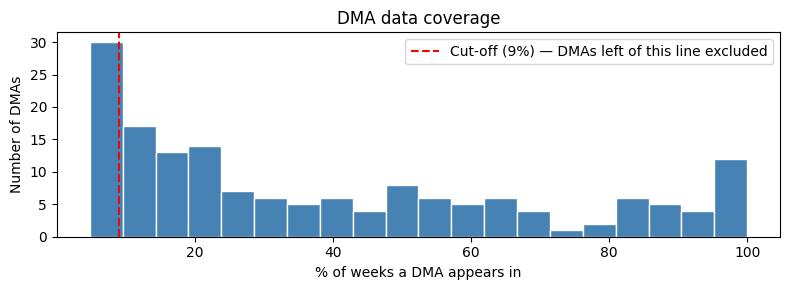

In [48]:
total_weeks = dma_weekly['week'].nunique()
total_dmas  = dma_weekly['dma'].nunique()

coverage = (
    dma_weekly.groupby('dma')['week'].nunique()
    .rename('weeks_present')
    .reset_index()
    .assign(pct = lambda d: d['weeks_present'] / total_weeks)
)

# Find the highest threshold that drops at most 20% of DMAs
max_drop = int(np.floor(total_dmas * 0.20))
threshold = next(
    t for t in np.arange(1.0, 0.0, -0.01)
    if (coverage['pct'] < t).sum() <= max_drop
)

keep  = coverage[coverage['pct'] >= threshold]['dma']
dropped = coverage[coverage['pct'] <  threshold][['dma', 'weeks_present', 'pct']]

print(f'Threshold : {threshold:.0%} of {total_weeks} weeks')
print(f'Kept      : {len(keep)} DMAs')
print(f'Dropped   : {len(dropped)} DMAs')

if len(dropped):
    print('\nDropped DMAs (incomplete data):')
    print(dropped.to_string(index=False))

dma_weekly = dma_weekly[dma_weekly['dma'].isin(keep)].copy()

# Chart: show which DMAs had gaps
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(coverage['pct'] * 100, bins=20, color='steelblue', edgecolor='white')
ax.axvline(threshold * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Cut-off ({threshold:.0%}) — DMAs left of this line excluded')
ax.set_xlabel('% of weeks a DMA appears in')
ax.set_ylabel('Number of DMAs')
ax.set_title('DMA data coverage')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 7 — Split DMAs into Treatment and Control

We use **stratified randomisation** — similar to how clinical trials work:

1. Group DMAs into 4 clusters of similar-sized markets
2. Within each cluster, randomly assign half to Treatment and half to Control

This ensures both groups have a similar mix of big and small markets.

In [54]:
# One row per DMA: average weekly bookings and variability
dma_stats = (
    dma_weekly.groupby('dma')['bookings']
    .agg(mean_bookings='mean', std_bookings='std')
    .reset_index()
    .fillna(0)
)

# Cluster DMAs into 4 groups by size and variability
X = StandardScaler().fit_transform(dma_stats[['mean_bookings', 'std_bookings']])
dma_stats['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

# Within each cluster, randomly assign half to Treatment
np.random.seed(42)
assignment = {}
for _, group in dma_stats.groupby('cluster'):
    dmas  = group['dma'].values
    treat = set(np.random.choice(dmas, len(dmas) // 2, replace=False))
    for dma in dmas:
        assignment[dma] = 'Treatment' if dma in treat else 'Control'

dma_stats['assignment']  = dma_stats['dma'].map(assignment)
dma_weekly['assignment'] = dma_weekly['dma'].map(assignment)

counts = dma_stats['assignment'].value_counts()
print(f'Treatment DMAs : {counts["Treatment"]}')
print(f'Control DMAs   : {counts["Control"]}')

Treatment DMAs : 64
Control DMAs   : 67


---
## Step 8 — Check the split is balanced

A good split means Treatment and Control have **similar booking volumes** and **similar trends over time**.

- Left chart: raw weekly totals per group
- Right chart: both groups indexed to 100 on week 1, so we can compare the *shape* of the trend without the size distorting things

Balance check:
assignment  n_dmas  total_bookings  avg_per_week
   Control      67            9930      4.982439
 Treatment      64            7257      4.106961


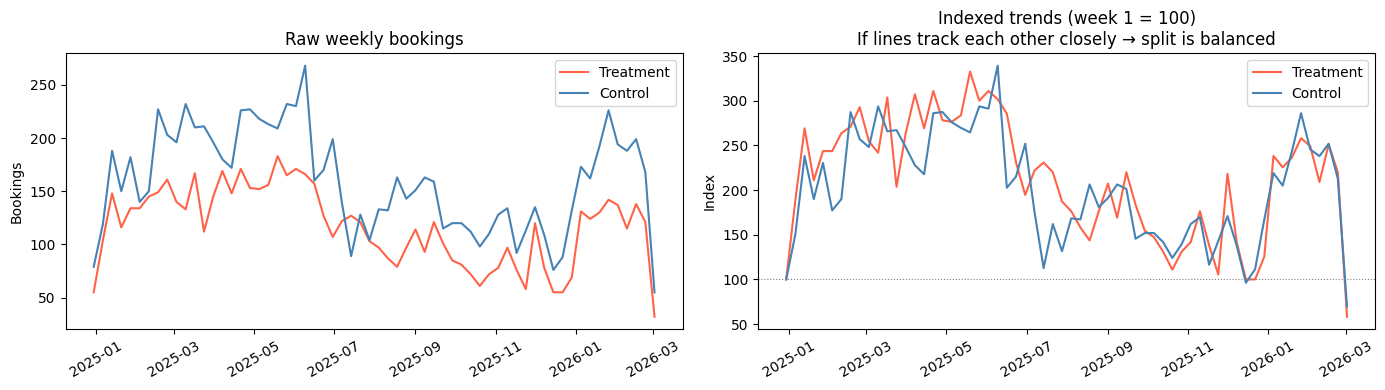

In [59]:
# Summary numbers
balance = (
    dma_weekly.groupby('assignment')
    .agg(n_dmas=('dma', 'nunique'), total_bookings=('bookings', 'sum'), avg_per_week=('bookings', 'mean'))
    .reset_index()
)
print('Balance check:')
print(balance.to_string(index=False))

# Weekly totals per group
weekly_group = (
    dma_weekly.groupby(['week', 'assignment'])['bookings']
    .sum().reset_index()
)

# Index to first week = 100
for grp in ['Treatment', 'Control']:
    mask = weekly_group['assignment'] == grp
    base = weekly_group.loc[mask, 'bookings'].iloc[0]
    weekly_group.loc[mask, 'indexed'] = weekly_group.loc[mask, 'bookings'] / base * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for grp, col in [('Treatment', 'tomato'), ('Control', 'steelblue')]:
    sub = weekly_group[weekly_group['assignment'] == grp]
    ax1.plot(sub['week'], sub['bookings'],  color=col, label=grp, linewidth=1.5)
    ax2.plot(sub['week'], sub['indexed'],   color=col, label=grp, linewidth=1.5)

ax1.set_title('Raw weekly bookings')
ax1.set_ylabel('Bookings')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend()
ax1.tick_params(axis='x', rotation=30)

ax2.axhline(100, color='grey', linestyle=':', linewidth=0.8)
ax2.set_title('Indexed trends (week 1 = 100)\nIf lines track each other closely → split is balanced')
ax2.set_ylabel('Index')
ax2.legend()
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Step 9 — Placebo test: natural variance between Treatment and Control

Before running the real experiment, we need to understand **how much Treatment and Control naturally drift apart** in historical data — where no campaign was running.

**How it works:**
- We slide an 8-week window across the full history
- For each window we measure: *did Treatment perform higher or lower than Control?*
- Since no treatment was ever applied, any difference is just **natural noise**
- The resulting distribution is our noise floor: a real campaign effect must be clearly outside this range to be detectable

If the distribution is tight and centred near 0% → the split is well-balanced.
If it is wide or shifted → there is a pre-existing imbalance between the groups.

In [ ]:
WINDOW = 8  # weeks

# Weekly totals per group as a simple time series
series = (
    dma_weekly.groupby(['week', 'assignment'])['bookings']
    .sum()
    .unstack('assignment')
    .sort_index()
    .reset_index()
)

# Slide an 8-week window across the full history.
# For each window, index both Treatment and Control to their own week-1 = 100.
# This removes any persistent size difference between the groups and focuses
# purely on relative movement — the same way the real experiment will be measured.
# The difference in average index (T_avg_index - C_avg_index) is the placebo lift.
results = []
for i in range(len(series) - WINDOW + 1):
    window = series.iloc[i : i + WINDOW].copy()

    # Index each group to its first week in this window = 100
    T_base = window['Treatment'].iloc[0]
    C_base = window['Control'].iloc[0]
    window['T_index'] = window['Treatment'] / T_base * 100
    window['C_index'] = window['Control']   / C_base * 100

    # Average index across the 8 weeks
    T_avg = window['T_index'].mean()
    C_avg = window['C_index'].mean()

    # Difference in index points: positive = Treatment grew faster than Control
    index_diff = T_avg - C_avg

    results.append({
        'window_start' : series.iloc[i]['week'],
        'T_avg_index'  : round(T_avg, 2),
        'C_avg_index'  : round(C_avg, 2),
        'index_diff'   : round(index_diff, 2),   # our placebo signal
    })

placebo = pd.DataFrame(results)

mean_diff = placebo['index_diff'].mean()
std_diff  = placebo['index_diff'].std()
p5, p95   = placebo['index_diff'].quantile([0.05, 0.95])

print(f'Windows tested     : {len(placebo)}')
print(f'Mean index diff    : {mean_diff:+.2f} pts  (should be near 0 if balanced)')
print(f'Std deviation      : {std_diff:.2f} pts')
print(f'90% range          : {p5:+.2f}  to  {p95:+.2f} index points')
print(f'\n→ During the real experiment, a detectable effect must push the index diff')
print(f'  clearly outside the {p5:+.2f} to {p95:+.2f} pts natural noise range.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left: distribution of index differences
ax1.hist(placebo['index_diff'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(0,         color='black', linestyle='-',  linewidth=1,   label='Zero (perfect balance)')
ax1.axvline(mean_diff, color='red',   linestyle='--', linewidth=1.5, label=f'Mean ({mean_diff:+.2f} pts)')
ax1.axvspan(p5, p95, alpha=0.12, color='steelblue',
            label=f'90% range  [{p5:+.2f},  {p95:+.2f}] pts')
ax1.set_xlabel('Index difference  (T avg index − C avg index, window start = 100)')
ax1.set_ylabel('Number of 8-week windows')
ax1.set_title('Natural variance between groups — indexed\n(placebo, no treatment applied)')
ax1.legend(fontsize=8)

# Right: index diff over time
ax2.plot(placebo['window_start'], placebo['index_diff'], color='steelblue', linewidth=1.2)
ax2.axhline(0,         color='black', linestyle='-',  linewidth=1)
ax2.axhline(mean_diff, color='red',   linestyle='--', linewidth=1, label=f'Mean ({mean_diff:+.2f} pts)')
ax2.fill_between(placebo['window_start'], p5, p95,
                 alpha=0.12, color='steelblue', label='90% range')
ax2.set_xlabel('Window start date')
ax2.set_ylabel('Index difference (pts)')
ax2.set_title('Index diff across historical windows\n(flat stable line = consistent balance over time)')
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

placebo.head(10)

---
## Step 9 — Booking volume per DMA

Each dot is one DMA. We want both groups to have a similar spread of large, medium and small markets — not one side dominated by a single giant DMA.

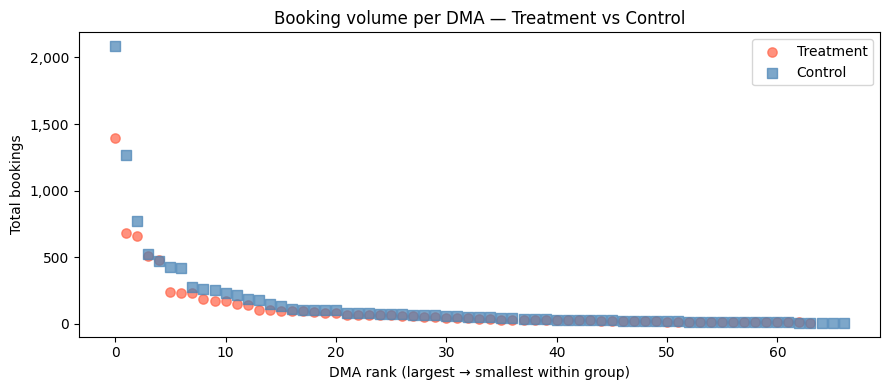

In [60]:
dma_totals = (
    dma_weekly.groupby(['dma', 'assignment'])['bookings']
    .sum().reset_index()
    .sort_values('bookings', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
for grp, col, mk in [('Treatment', 'tomato', 'o'), ('Control', 'steelblue', 's')]:
    sub = dma_totals[dma_totals['assignment'] == grp].reset_index(drop=True)
    ax.scatter(range(len(sub)), sub['bookings'], color=col, marker=mk,
               label=grp, alpha=0.7, s=45)

ax.set_xlabel('DMA rank (largest → smallest within group)')
ax.set_ylabel('Total bookings')
ax.set_title('Booking volume per DMA — Treatment vs Control')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 10 — Save the final split

Write the DMA assignment to a CSV file. This is the file that will be used to set up campaign targeting.

In [63]:
final_split = (
    dma_weekly.groupby(['dma', 'assignment'])
    .agg(total_bookings=('bookings', 'sum'), avg_weekly=('bookings', 'mean'))
    .reset_index()
    .sort_values(['assignment', 'total_bookings'], ascending=[True, False])
    .round(1)
)

out_path = os.path.join(BASE_DIR, 'dma_final_split.csv')
final_split.to_csv(out_path, index=False)
print(f'Saved to: {out_path}')
print(f'\nTreatment DMAs: {(final_split["assignment"] == "Treatment").sum()}')
print(f'Control DMAs  : {(final_split["assignment"] == "Control").sum()}')
final_split.head(10)

Saved to: /Users/kate/geo-experiment-rct/dma_final_split.csv

Treatment DMAs: 64
Control DMAs  : 67


,dma,assignment,total_bookings,avg_weekly
80,NEW YORK,Control,2085,33.6
106,SAN FRANCISCO - OAK - SAN JOSE,Control,1269,20.5
124,"WASHINGTON, DC (HAGRSTWN)",Control,774,12.7
3,ATLANTA,Control,521,8.4
109,SEATTLE - TACOMA,Control,474,7.6
88,PHILADELPHIA,Control,426,7.1
31,DENVER,Control,415,6.8
52,HOUSTON,Control,277,4.8
5,AUSTIN,Control,263,4.7
89,PHOENIX (PRESCOTT),Control,251,4.6


---
## Step 11 — Power: what lift can we detect?

Power tells us: *if the campaign actually lifts bookings by X%, how likely are we to measure and confirm that lift?*

- **Green (≥ 85%)** = we're very likely to detect the effect
- **Red (< 85%)** = we might miss it even if it's real

This reads results from the simulation already run by `geo_test_v2.py`.

          3% lift  5% lift  10% lift  20% lift
8 weeks         8       15        34        67
12 weeks        8       13        30        80
16 weeks       10       10        30        85


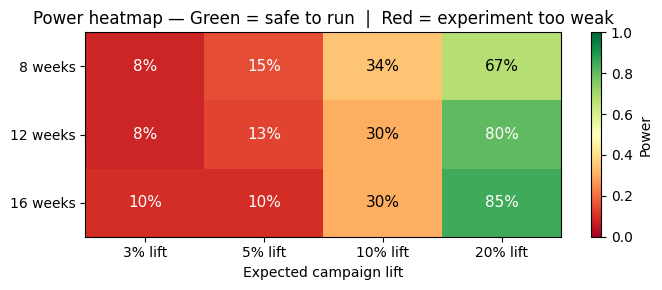

In [65]:
power_path = os.path.join(BASE_DIR, 'power_results_fixed_split.csv')

if not os.path.exists(power_path):
    print('File not found: power_results_fixed_split.csv')
    print('Run geo_test_v2.py first, then re-run this cell.')
else:
    power = pd.read_csv(power_path)

    # Table: rows = test duration, columns = lift size
    table = power.pivot(index='test_weeks', columns='effect_pct', values='power_fixed_split')
    table.columns = [f'{c:.0f}% lift' for c in table.columns]
    table.index   = [f'{w} weeks'     for w in table.index]
    print((table * 100).round(0).astype(int).to_string())

    # Heatmap
    fig, ax = plt.subplots(figsize=(7, 3))
    im = ax.imshow(table.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_xlabel('Expected campaign lift')
    ax.set_title('Power heatmap — Green = safe to run  |  Red = experiment too weak')
    for i in range(len(table.index)):
        for j in range(len(table.columns)):
            v = table.values[i, j]
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=11,
                    color='black' if 0.25 < v < 0.75 else 'white')
    plt.colorbar(im, ax=ax, label='Power')
    plt.tight_layout()
    plt.show()

---
## Summary

| Step | What we did |
|------|-------------|
| 1–2  | Loaded Braintree data, kept US transactions, removed refunds |
| 3    | Rolled up to weekly bookings per ZIP code |
| 4    | Mapped each ZIP to its DMA (media market) |
| 5    | Rolled up to weekly bookings per DMA |
| 6    | Removed DMAs with incomplete data |
| 7    | Split DMAs into Treatment / Control using stratified randomisation |
| 8–9  | Verified the split is balanced |
| 10   | Saved `dma_final_split.csv` |
| 11   | Confirmed we have enough power to detect the expected lift |

**Output file:** `dma_final_split.csv` — the definitive list of which DMAs are Treatment and which are Control.